**Load Dataset**

You can find dataset at this link

[Kaggle Dataset](https://www.kaggle.com/datasets/ahemateja19bec1025/traffic-sign-dataset-classification?resource=download)

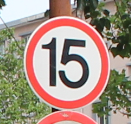

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ahemateja19bec1025/traffic-sign-dataset-classification")

print("Path to dataset files:", path)

100%|██████████| 190M/190M [00:01<00:00, 146MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ahemateja19bec1025/traffic-sign-dataset-classification/versions/2


**Check for files in path above**

In [ ]:
# prompt: list all file in path

import os

def list_files(path):
  """Lists all files in the given path.

  Args:
    path: The path to the directory.
  """
  for filename in os.listdir(path):
    print(filename)

# Example usage (assuming 'path' variable is defined from the previous code)
list_files(path)


labels.csv
traffic_Data


**Create Dataset**

-  loop labels.csv
-  loop folder of row["ClassId"]
-  Add images and Labels to Array

In [ ]:
# prompt: create an CNN training with data is images and labels.csv using keras

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from PIL import Image
import os

# Assuming 'path' variable holds the dataset path from the previous code.
# Replace with your actual path if necessary.
# path = ...

# Load labels
labels_df = pd.read_csv(os.path.join(path, 'labels.csv'))

# Preprocessing
image_size = (32, 32)
images = []
labels = []
for index, row in labels_df.iterrows():
    folder_path = os.path.join(path, 'traffic_Data', 'DATA', str(row['ClassId']))
    try:
        for filename in os.listdir(folder_path):
          image_path = os.path.join(folder_path, filename)
          if os.path.isfile(image_path):
            img = Image.open(image_path).convert("RGB").resize(image_size)
            img_array = np.array(img) / 255.0  # Normalize pixel values
            images.append(img_array)
            labels.append(row['ClassId'])
    except Exception as e:
        print(f"Error processing image {folder_path}: {e}")

images = np.array(images)
labels = np.array(labels)

print(len(images))
print(len(labels))


4170
4170


**Train Test Split**

In [ ]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(images, labels, test_size=0.2, random_state=42)

**Define Model**

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


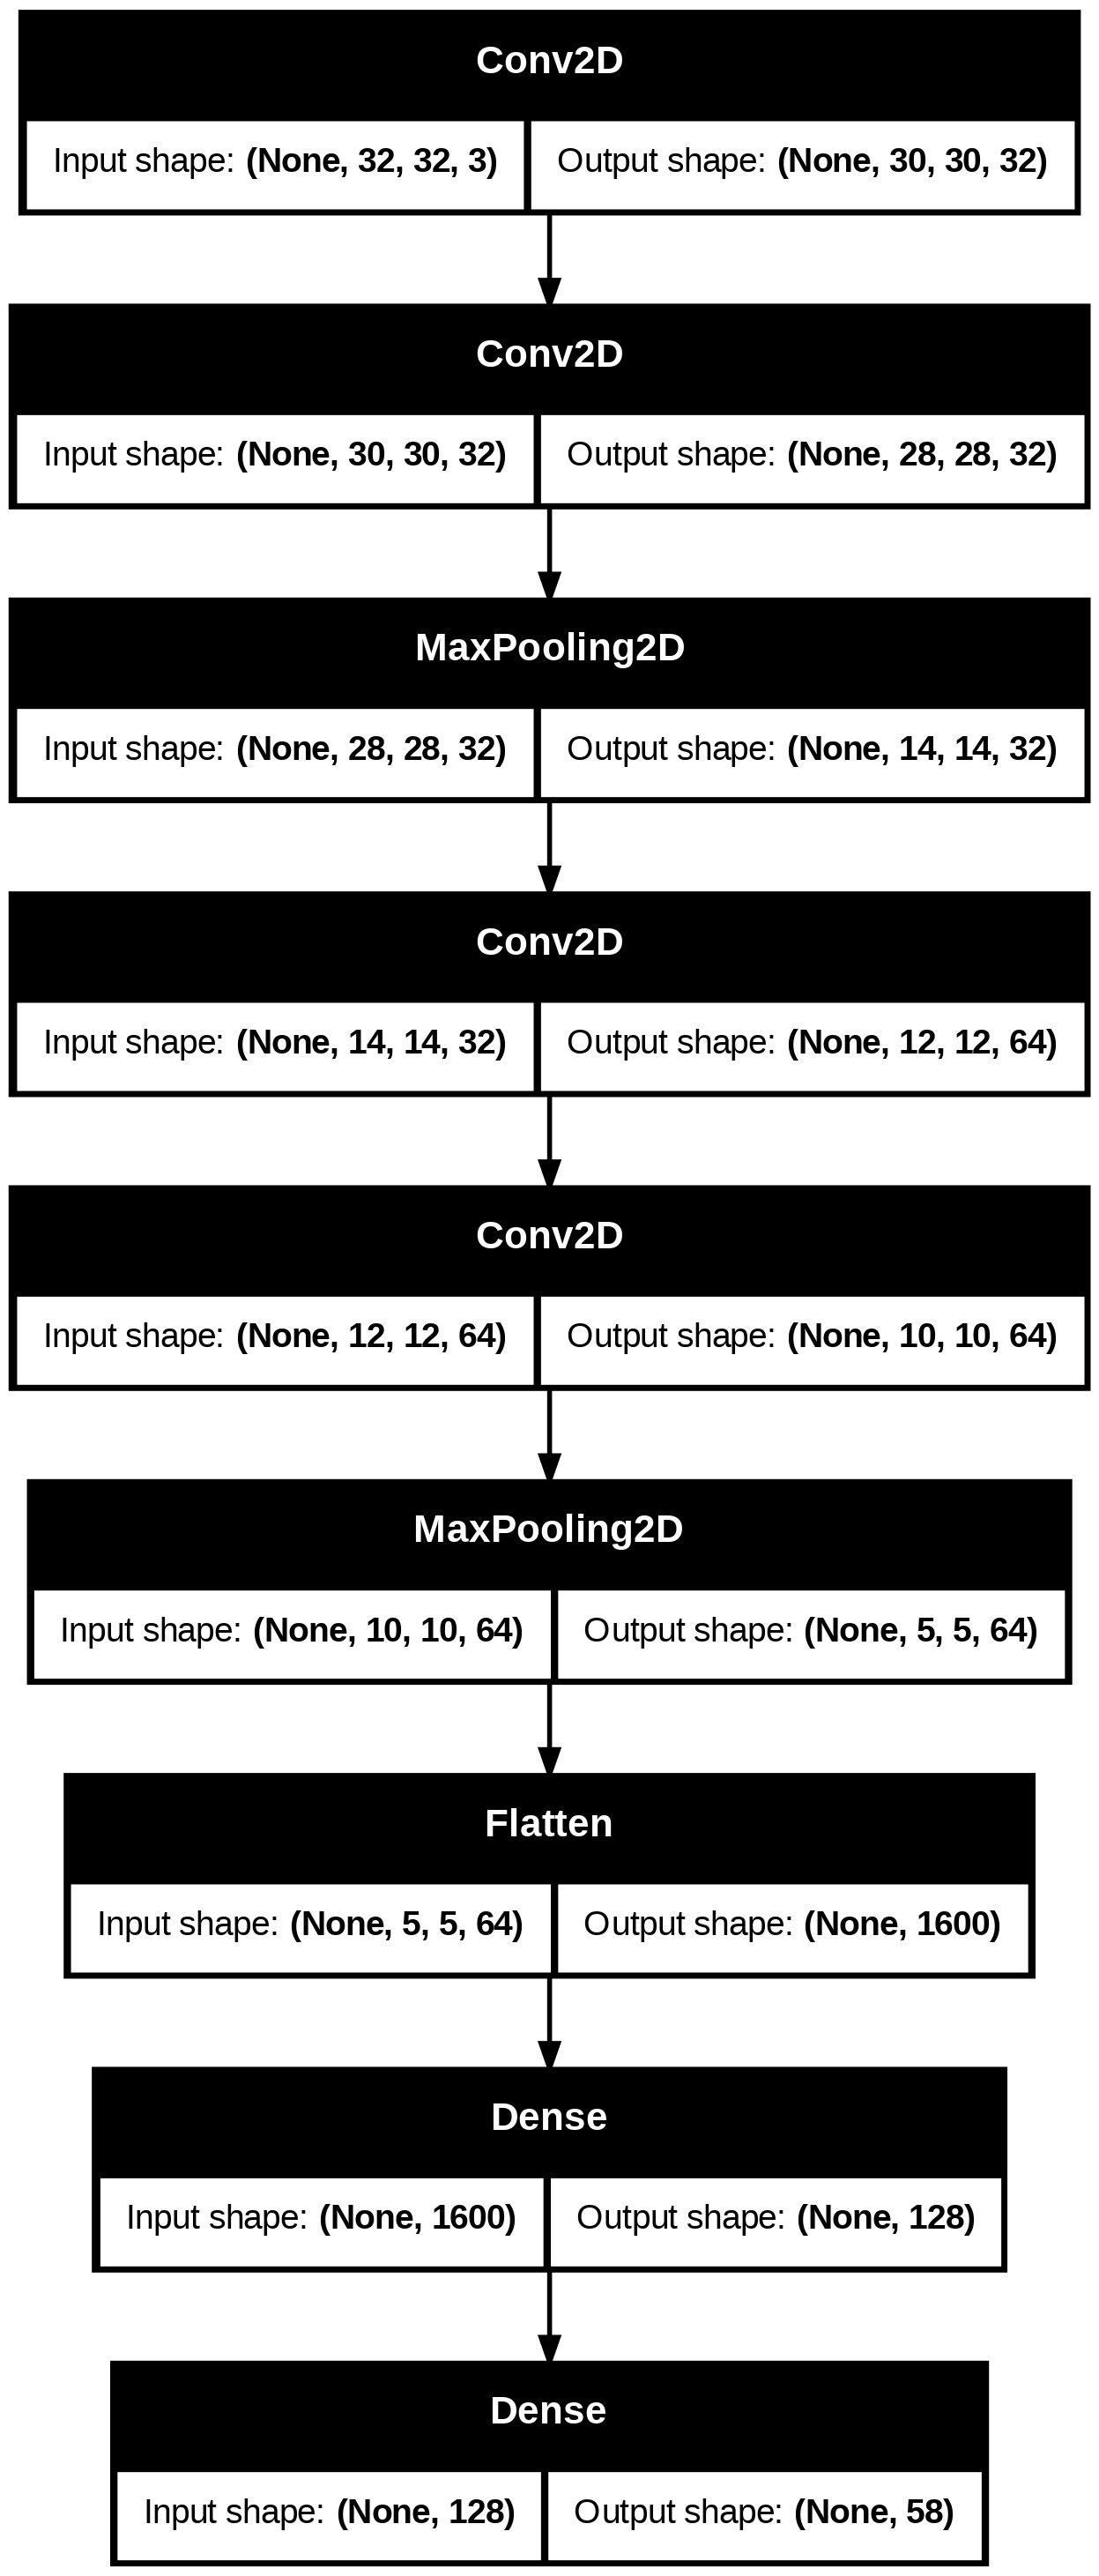

In [ ]:
# Define the model
num_classes = len(np.unique(labels)) # Ensure 'labels' is defined

model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    Conv2D(32, (3, 3), activation='relu'), # Added Conv2D
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Conv2D(64, (3, 3), activation='relu'), # Added Conv2D
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy if labels are integers
              metrics=['accuracy'])

keras.utils.plot_model(model, show_shapes=True)

**Train Model**

In [ ]:
# Convert labels to numerical representation using LabelEncoder
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

# Now, proceed with training your model
model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Evaluate the model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

Epoch 1/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 113ms/step - accuracy: 1.0000 - loss: 1.2895e-04 - val_accuracy: 0.9904 - val_loss: 0.1889
Epoch 2/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 19s 100ms/step - accuracy: 1.0000 - loss: 9.3611e-05 - val_accuracy: 0.9904 - val_loss: 0.1928
Epoch 3/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 9s 88ms/step - accuracy: 1.0000 - loss: 1.0484e-04 - val_accuracy: 0.9904 - val_loss: 0.1958
Epoch 4/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 12s 102ms/step - accuracy: 1.0000 - loss: 8.4126e-05 - val_accuracy: 0.9904 - val_loss: 0.1988
Epoch 5/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 111ms/step - accuracy: 1.0000 - loss: 7.2013e-05 - val_accuracy: 0.9904 - val_loss: 0.2018
Epoch 6/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 102ms/step - accuracy: 1.0000 - loss: 6.5071e-05 - val_accuracy: 0.9904 - val_loss: 0.2047
Epoch 7/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 21s 106ms/step - accuracy: 1.0000 - loss: 5.6969e-05 - val_accuracy: 0.9904 - val_loss: 0.2073
Epoch 8/10
105/105 ━━━━━━━━━━━━━━━━━━━━ 20s 103ms/step - 

In [ ]:
from google.colab import drive
import shutil
drive.mount('/content/drive')

drive_save_path = '/content/drive/MyDrive/Colab Notebooks/weights'
os.makedirs(drive_save_path, exist_ok=True)

model.save_weights("traffic_sign.weights.h5")
shutil.copy("traffic_sign.weights.h5", drive_save_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Load Saved Weight (Optional)**

In [ ]:
from google.colab import drive
import shutil
drive.mount('/content/drive')

drive_load_path = '/content/drive/MyDrive/Colab Notebooks/weights/traffic_sign.weights.h5'
model.load_weights(drive_load_path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 26 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
img_path = os.path.join(path, 'traffic_Data', 'TEST', '004_0001_j.png')
# img_path = os.path.join(path, 'traffic_Data', 'DATA', '37', '037_0002.png')
img = keras.utils.load_img(img_path, target_size=image_size)

import matplotlib.pyplot as plt
plt.imshow(img)

img_array = keras.utils.img_to_array(img)
img_array = keras.ops.expand_dims(img_array, 0)  # Create batch axis

predictions = model.predict(img_array)
print(predictions[0])
found_index = np.argmax(predictions[0])
label = labels_df.iloc[found_index]['Name']
print(labels_df.iloc[[found_index]])

score = float(keras.ops.sigmoid(predictions[0][found_index]))
print(f'{(score * 100):.2f}% of {label}')